In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

,ID ANSSI,Titre ANSSI,Type,Date,CVE,CVSS,Base Severity,CWE,EPSS,Lien,Description,Éditeur,Produit,Versions affectées
0,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alertes,NaN,CVE-2021-20016,NaN,Non disponible,CWE-89,0.79818,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,A SQL-Injection vulnerability in the SonicWall...,SonicWall,SonicWall SMA100,SMA100 build version 10.x
1,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alertes,NaN,CVE-2014-6271,NaN,Non disponible,Non disponible,0.94220,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,GNU Bash through 4.3 processes trailing string...,NaN,NaN,NaN
2,CERTFR-2021-ALE-002,[MàJ] Vulnérabilité dans Google Chrome et Micr...,Alertes,NaN,CVE-2021-21148,NaN,Non disponible,Non disponible,0.19904,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Heap buffer overflow in V8 in Google Chrome pr...,Google,Chrome,unspecified
3,CERTFR-2021-ALE-003,[MàJ] Vulnérabilité dans VMware vCenter Server,Alertes,NaN,CVE-2021-21972,NaN,Non disponible,Non disponible,0.93821,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,The vSphere Client (HTML5) contains a remote c...,NaN,VMware vCenter Server,"7.x before 7.0 U1c, 6.7 before 6.7 U3l, 6.5 be..."
4,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alertes,NaN,CVE-2021-26412,9.1,Critical,Non disponible,0.24204,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Microsoft Exchange Server Remote Code Executio...,Microsoft,Microsoft Exchange Server 2013 Cumulative Upda...,15.00.0


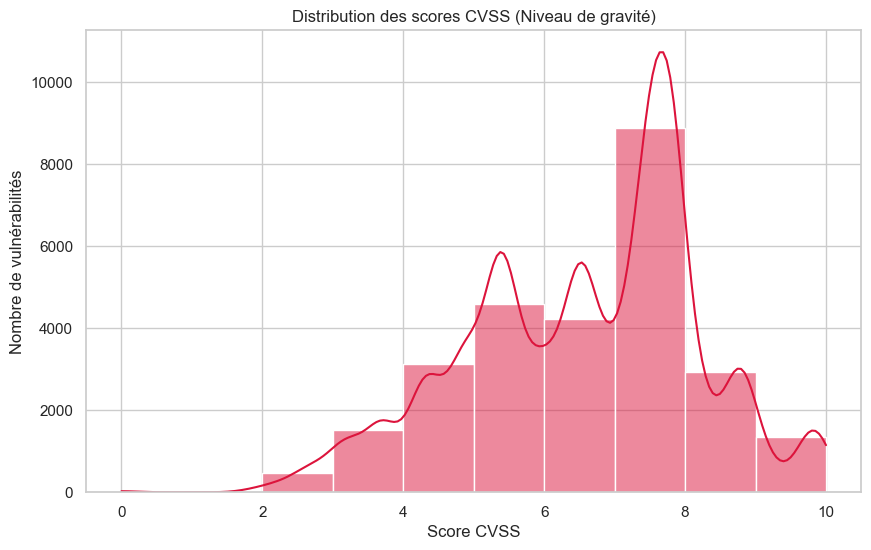

C:\Users\timot\AppData\Local\Temp\ipykernel_7028\4274928906.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_cwe.values, y=top_10_cwe.index, palette="pastel")


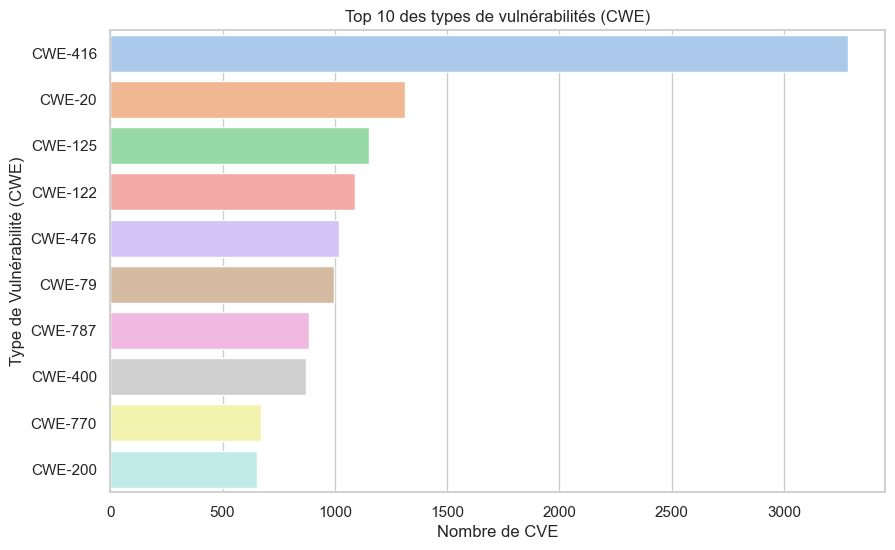

C:\Users\timot\AppData\Local\Temp\ipykernel_7028\4274928906.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_editeurs.values, y=top_10_editeurs.index, palette='viridis')


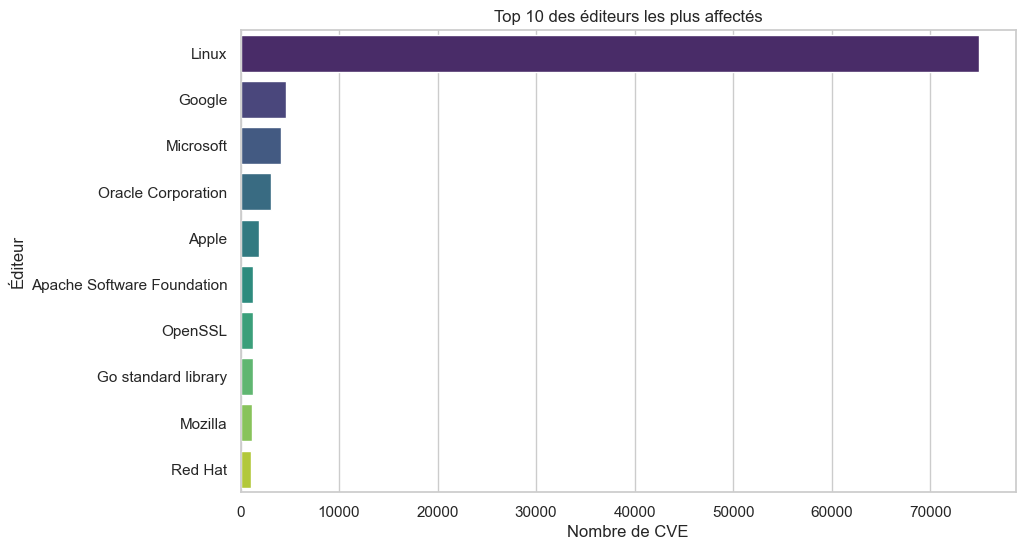

In [9]:
df = pd.read_csv('donnees_anssi_enrichies.csv', sep=',')
display(df.head())

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['CVSS'].dropna(), bins=10, kde=True, color='crimson')
plt.title('Distribution des scores CVSS (Niveau de gravité)')
plt.xlabel('Score CVSS')
plt.ylabel('Nombre de vulnérabilités')
plt.show()

plt.figure(figsize=(10, 6))
df_cwe_connus = df[df['CWE'] != 'Non disponible']
top_10_cwe = df_cwe_connus['CWE'].value_counts().head(10)

sns.barplot(x=top_10_cwe.values, y=top_10_cwe.index, palette="pastel")
plt.title('Top 10 des types de vulnérabilités (CWE)')
plt.xlabel('Nombre de CVE')
plt.ylabel('Type de Vulnérabilité (CWE)')
plt.show()

plt.figure(figsize=(10, 6))
df_editeurs_connus = df[(df['Éditeur'] != 'n/a') & (df['Éditeur'] != 'Non disponible')]
top_10_editeurs = df_editeurs_connus['Éditeur'].value_counts().head(10)

sns.barplot(x=top_10_editeurs.values, y=top_10_editeurs.index, palette='viridis')
plt.title('Top 10 des éditeurs les plus affectés')
plt.xlabel('Nombre de CVE')
plt.ylabel('Éditeur')
plt.show()


[Modèle Non Supervisé : K-Means Clustering]


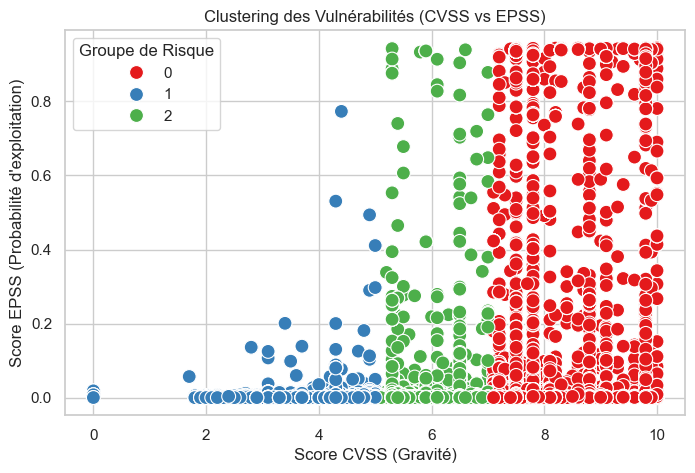


[Modèle Supervisé : Random Forest Regressor]
Validation du modèle :
- Erreur Quadratique Moyenne (MSE) : 0.0109
- Score R2 : 0.2646


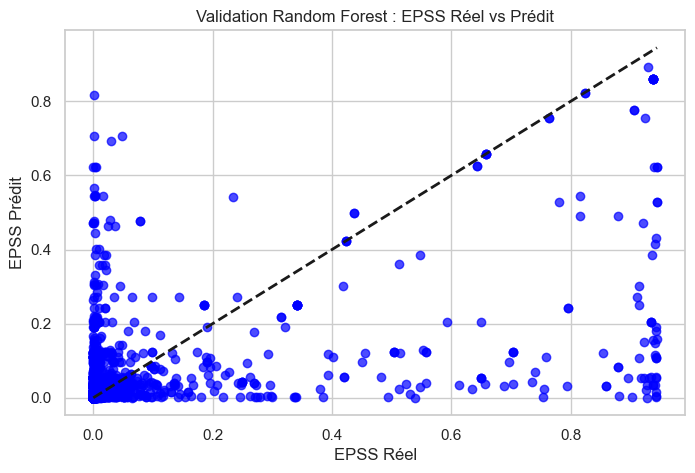

In [12]:
df_ml = df.copy()

df_ml = df_ml.dropna(subset=['CVSS', 'EPSS'])

le_cwe = LabelEncoder()
df_ml['CWE_encoded'] = le_cwe.fit_transform(df_ml['CWE'])

print("\n[Modèle Non Supervisé : K-Means Clustering]")
X_unsup = df_ml[['CVSS', 'EPSS']]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml['Cluster_Risque'] = kmeans.fit_predict(X_unsup)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_ml, x='CVSS', y='EPSS', hue='Cluster_Risque', palette='Set1', s=100)
plt.title("Clustering des Vulnérabilités (CVSS vs EPSS)")
plt.xlabel("Score CVSS (Gravité)")
plt.ylabel("Score EPSS (Probabilité d'exploitation)")
plt.legend(title='Groupe de Risque')
plt.show()

print("\n[Modèle Supervisé : Random Forest Regressor]")
X_sup = df_ml[['CVSS', 'CWE_encoded']]
y_sup = df_ml['EPSS']

X_train, X_test, y_train, y_test = train_test_split(X_sup, y_sup, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Validation du modèle :")
print(f"- Erreur Quadratique Moyenne (MSE) : {mse:.4f}")
print(f"- Score R2 : {r2:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Ligne de perfection
plt.title("Validation Random Forest : EPSS Réel vs Prédit")
plt.xlabel("EPSS Réel")
plt.ylabel("EPSS Prédit")
plt.show()

In [13]:
from_email = 'alertes.td.final@gmail.com'
password = 'zfjw jnhx jpks jxkf'
to_email = 'timotheerobin48@gmail.com'

In [14]:
def send_email(to_email, subject, body):
    msg = MIMEText(body) 
    msg['From'] = from_email 
    msg['To'] = to_email
    msg['Subject'] = subject
    
    try:
        server = smtplib.SMTP('smtp.gmail.com', 587) 
        server.starttls() 
        server.login(from_email, password) 
        server.sendmail(from_email, to_email, msg.as_string())
        server.quit()
        print(f"Alerte envoyée avec succès à {to_email}")
    except Exception as e:
        print(f"Erreur lors de l'envoi de l'email : {e}")

def verifier_et_alerter(df, email_destinataire):
    alertes_critiques = df[df['CVSS'] >= 9.0]
    
    if alertes_critiques.empty:
        print("Aucune vulnérabilité critique détectée. Aucun email envoyé.")
        return
        
    print(f"{len(alertes_critiques)} vulnérabilités critiques trouvées.")
    print("Pour éviter le spam, nous n'allons envoyer des alertes que pour les 3 premières.\n")
    
    # On limite à 3 pour la démo pour éviter le spam
    for index, row in alertes_critiques.head(3).iterrows():
        sujet = f"Alerte CVE critique : {row['CVE']} sur {row['Produit']}"
        
        corps = f"""
Bonjour,

Une vulnérabilité critique a été publiée par l'ANSSI.

Détails :
- Produit affecté : {row['Produit']} (Éditeur : {row['Éditeur']})
- CVE : {row['CVE']}
- Score CVSS : {row['CVSS']} ({row['Base Severity']})
- Probabilité d'exploitation (EPSS) : {row['EPSS']}

Description :
{row['Description']}

Lien ANSSI : {row['Lien']}

Veuillez patcher vos systèmes (Versions affectées : {row['Versions affectées']}) immédiatement.
"""
        
        print("--- PRÉPARATION DE L'ALERTE ---")
        print(f"Sujet : {sujet}")
        print("Envoi en cours...")
        send_email(email_destinataire, sujet, corps)
        print("-" * 30)

verifier_et_alerter(df, to_email)

1341 vulnérabilités critiques trouvées.
Pour éviter le spam, nous n'allons envoyer des alertes que pour les 3 premières.

--- PRÉPARATION DE L'ALERTE ---
Sujet : Alerte CVE critique : CVE-2021-26412 sur Microsoft Exchange Server 2013 Cumulative Update 23
Envoi en cours...
Alerte envoyée avec succès à timotheerobin48@gmail.com
------------------------------
--- PRÉPARATION DE L'ALERTE ---
Sujet : Alerte CVE critique : CVE-2021-27078 sur Microsoft Exchange Server 2016 Cumulative Update 19
Envoi en cours...
Alerte envoyée avec succès à timotheerobin48@gmail.com
------------------------------
--- PRÉPARATION DE L'ALERTE ---
Sujet : Alerte CVE critique : CVE-2021-26855 sur Microsoft Exchange Server 2016 Cumulative Update 19
Envoi en cours...
Alerte envoyée avec succès à timotheerobin48@gmail.com
------------------------------
